# 26_YOLO 모델에 맞게 데이터 변형하기

## 학습목표 
- 1. YOLO 모델이 요구하는 데이터의 라벨에 맞게 데이터를 변형합니다.    

In [1]:
import os #로컬 컴퓨터에서 데이터셋을 불러오기 위해
import cv2 # 시각화 해서 표현하기 위함
import numpy as np #이미지 픽셀 데이터를 numpy 형태로 표현함
import json #개별 라벨을 읽어들어오게 함

import torch #훈련
from torch.utils.data import Dataset, DataLoader #커스텀 데이터셋을 만들기 위함
from torchvision import transforms #torchvision -> 딥러닝(이미지) 수행하는 클래스 이름 #transform 이미지를 조절
from PIL import Image #-> 이미지를 표현할 수 있는 파이썬 라이브러리 
import matplotlib.pyplot as plt

In [6]:
label_list = 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/train_list.txt'
image_list = 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/train_image_list.txt'

In [7]:
with open(image_list, "r", encoding="utf-8") as f:
    images = [line.strip() for line in f]  # 개행 문자 제거 후 리스트로 변환

In [3]:
with open(label_list, "r", encoding="utf-8") as f:
    labels = [line.strip() for line in f]  # 개행 문자 제거 후 리스트로 변환

In [9]:
images[:2]

['C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Images/upper_29244.png',
 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Images/upper_29249.png']

In [10]:
labels[:2]

['C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Labels/upper_29244.json',
 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/Labels/upper_29249.json']

In [5]:
with open(labels[0], 'r') as f:
    annotations = json.load(f)

### 데이터 확인해보기

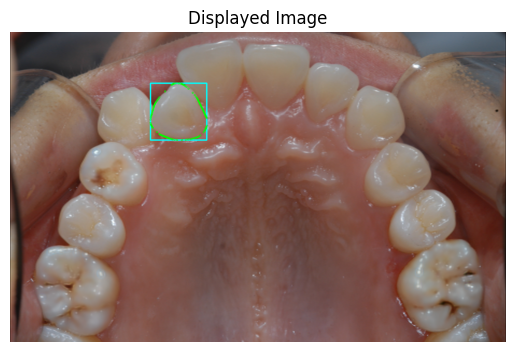

In [11]:
# x, y 좌표를 각각 추출
# p[0] 기준으로 오름차순 정렬
sorted_xs = sorted(annotations['tooth'][1]['segmentation'], key=lambda p: p[0])

start_x = sorted_xs[0][0] 
end_x = sorted_xs[-1][0]

sorted_ys = sorted(annotations['tooth'][1]['segmentation'], key=lambda p: p[1])
start_y = sorted_ys[0][1] 
end_y = sorted_ys[-1][1]

image_rgb = Image.open(images[0])
image = np.array(image_rgb)

#cv_image, start_point, end_point, color, thickness
result_image = cv2.rectangle(image, (start_x, start_y), (end_x, end_y), (0, 255, 255), 3)

sorted_points = sorted(annotations['tooth'][1]['segmentation'], key=lambda p: p[0])
for x, y in sorted_points:
    result_image = cv2.circle(image, (x, y), 3, (0, 255, 0))

result_pil_image = Image.fromarray(result_image)

# 이미지 출력
plt.imshow(result_pil_image)
plt.axis('off')  # 축 제거
plt.title('Displayed Image')  # 제목 설정
plt.show()

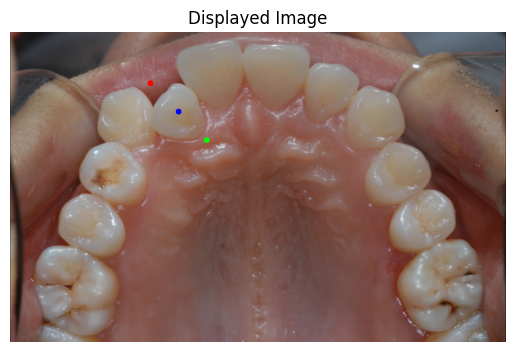

In [14]:
sorted_xs = sorted(annotations['tooth'][1]['segmentation'], key=lambda p: p[0])

#여기서, (start_x, start_y)는 사각형의 왼쪽 시작점
#(end_x, end_y)는 사각형의 오른쪽 끝점
start_x = sorted_xs[0][0] 
end_x = sorted_xs[-1][0]

sorted_ys = sorted(annotations['tooth'][1]['segmentation'], key=lambda p: p[1])
start_y = sorted_ys[0][1] 
end_y = sorted_ys[-1][1]

image_rgb = Image.open(images[0])
image = np.array(image_rgb)

#시작점을 Red,
#끝점을 Green으로 그림
result_image = cv2.circle(image, (start_x, start_y), 10, (255, 0, 0), -1)
result_image = cv2.circle(image, (end_x, end_y), 10, (0, 255, 0), -1)

mid_x = (start_x + end_x)/2 
mid_y = (start_y + end_y)/2

#중점을 Blue 로 표현하다
result_image = cv2.circle(image, (int(mid_x), int(mid_y)), 10, (0, 0, 255), -1)
result_pil_image = Image.fromarray(result_image)

# 이미지 출력
plt.imshow(result_pil_image)
plt.axis('off')  # 축 제거
plt.title('Displayed Image')  # 제목 설정
plt.show()

#### 시작점과 끝 점의 수치 변환

In [15]:
width = start_x - end_x
height = start_y - end_y      

print(f"WIDTH : {width} , HEIGHT : {height}")

WIDTH : -196 , HEIGHT : -198


In [16]:
image = np.array(image_rgb)
print(f"{image.shape}")

(1080, 1728, 3)


In [ ]:
W, H, C = image.shape   

width = abs(start_x - end_x) / W
height = abs(start_y - end_y)  / H

print(f"WIDTH : {width} , HEIGHT : {height}")

### 함수화하여 각 annotations 데이터마다 충치에 대한 라벨을 한 줄씩 입력하도록 하기

In [25]:
def return_bbox(image_path, annotations_lab):

    with open(annotations_lab, 'r') as f:
        annotations = json.load(f)

    image_rgb = Image.open(image_path)
    image = np.array(image_rgb)

    #너비, 높이
    W, H, C = image.shape   
    
    bounding_boxes = []
    for i in range(len(annotations['tooth'])):
        if annotations['tooth'][i]['decayed'] == True:
            # x, y 좌표를 각각 추출
            # p[0] 기준으로 오름차순 정렬
            sorted_xs = sorted(annotations['tooth'][i]['segmentation'], key=lambda p: p[0])
            
            start_x = sorted_xs[0][0] 
            end_x = sorted_xs[-1][0]
            
            sorted_ys = sorted(annotations['tooth'][i]['segmentation'], key=lambda p: p[1])
            start_y = sorted_ys[0][1] 
            end_y = sorted_ys[-1][1]

            # 너비와 높이 계산
            width = abs(start_x - end_x) / W
            height = abs(start_y - end_y)  / H
            
            # 중심점 계산
            mid_x = ((start_x + end_x)/2 )/W 
            mid_y = ((start_y + end_y)/2 )/H

            bounding_boxes.append([0, mid_x, mid_y, width, height])
    
    return bounding_boxes

### 하나의 annotation 파일에 대해 동작해보기

In [26]:
bbox = return_bbox(images[0], labels[0])

In [27]:
bbox

[[0,
  0.3337962962962963,
  0.28703703703703703,
  0.2212962962962963,
  0.12731481481481483],
 [0,
  0.21574074074074073,
  0.5217013888888888,
  0.2796296296296296,
  0.18229166666666666],
 [0,
  1.387037037037037,
  0.5112847222222222,
  0.2796296296296296,
  0.1869212962962963]]

### 제대로 동작하는지 확인하기

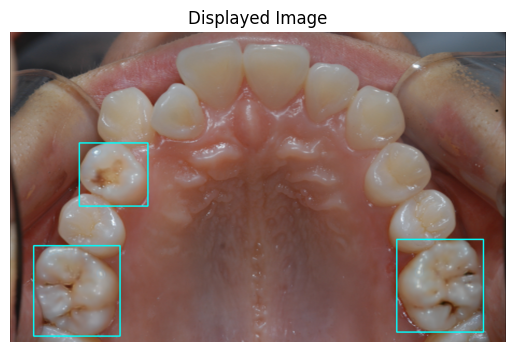

In [20]:
def draw_list(image_path, labels):
    image_rgb = Image.open(image_path)
    image = np.array(image_rgb)

    #너비, 높이
    W, H, C = image.shape   

    for i in range(len(labels)):
        x, y, w, h = labels[i]

        w = w*0.5
        h = h*0.5
        result_image = cv2.rectangle(image, (int((x-w)*W), int((y-h)*H)), 
                                             (int((x+w)*W), int((y+h)*H)), (0, 255, 255), 3)

    return result_image

result_pil_image = draw_list(images[0], bbox)

# 이미지 출력
plt.imshow(result_pil_image)
plt.axis('off')  # 축 제거
plt.title('Displayed Image')  # 제목 설정
plt.show()

### 이를 라벨로 변경해서 txt 파일로 저장하기

In [23]:
print(images[0].split('/')[-1].split('.')[-2])

upper_29244


In [37]:
save_dir = 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/YOLO/Train/labels'
for i in range(len(labels)):
    bbox = return_bbox(images[i], labels[i])
    file_name = images[i].split('/')[-1].split('.')[-2] + '.txt'

    save_like = os.path.join(save_dir, file_name)
    
    with open(save_like, "w", encoding="utf-8") as f:
        for item in bbox:
            f.write(" ".join(map(str, item)) + "\n")  # 개행 문자 추가하여 한 줄씩 저장

#### Valid

In [38]:
#동일하게, valid에도 적용해주기
label_list = 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/valid_list.txt'
with open(label_list, "r", encoding="utf-8") as f:
    labels = [line.strip() for line in f]  # 개행 문자 제거 후 리스트로 변환

image_list = 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/valid_image_list.txt'    
with open(image_list, "r", encoding="utf-8") as f:
    images = [line.strip() for line in f]  # 개행 문자 제거 후 리스트로 변환

save_dir = 'C:/Users/jeong/Desktop/최종코드/Datasets/Proj_1/YOLO/Valid/labels'
for i in range(len(labels)):
    bbox = return_bbox(images[i], labels[i])
    file_name = images[i].split('/')[-1].split('.')[-2] + '.txt'

    save_like = os.path.join(save_dir, file_name)
    
    with open(save_like, "w", encoding="utf-8") as f:
        for item in bbox:
            f.write(" ".join(map(str, item)) + "\n")  # 개행 문자 추가하여 한 줄씩 저장